## Resumen

- Existe poca linealidad para un modelo de regresión, así que este modelo se descarta
- Tratar outliers, valores nulos, fechas fuera del rango y otras tareas de preprocesamiento para Random Forest

In [21]:
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 6)

In [22]:
df_path = r"c:\Users\PC\OneDrive\Desktop\tb2\nyc-taxi\data\yellow_tripdata_2026.parquet"
df = pl.read_parquet(df_path)

print(f"Shape: {df.shape[0]} filas × {df.shape[1]} columnas")
print(f"Tamaño en memoria: {df.estimated_size() / 1024 / 1024:.2f} MB")

Shape: 11077206 filas × 20 columnas
Tamaño en memoria: 1488.21 MB


In [23]:
print("=" * 80)
print("ESQUEMA DEL DATASET")
print("=" * 80)
schema = df.schema
for i, (col_name, col_type) in enumerate(schema.items(), 1):
    print(f"{i:2}. {col_name:30} {str(col_type):20}")

print("\n" + "=" * 80)
print("PRIMERAS 5 FILAS")
print("=" * 80)
print(df.head(5))

ESQUEMA DEL DATASET
 1. VendorID                       Int32               
 2. tpep_pickup_datetime           Datetime(time_unit='us', time_zone=None)
 3. tpep_dropoff_datetime          Datetime(time_unit='us', time_zone=None)
 4. passenger_count                Int64               
 5. trip_distance                  Float64             
 6. RatecodeID                     Int64               
 7. store_and_fwd_flag             String              
 8. PULocationID                   Int32               
 9. DOLocationID                   Int32               
10. payment_type                   Int64               
11. fare_amount                    Float64             
12. extra                          Float64             
13. mta_tax                        Float64             
14. tip_amount                     Float64             
15. tolls_amount                   Float64             
16. improvement_surcharge          Float64             
17. total_amount                   Float64  

In [24]:
print("=" * 80)
print("ANÁLISIS DE VALORES FALTANTES (NULL)")
print("=" * 80)

null_counts = df.select(
    [pl.col(col).null_count().alias(col) for col in df.columns]
).to_dict(as_series=False)

total_rows = df.shape[0]
missing_data = []

for col in df.columns:
    null_count = null_counts[col][0]
    null_pct = (null_count / total_rows) * 100 if total_rows > 0 else 0
    missing_data.append({
        'Columna': col,
        'Valores_NULL': null_count,
        'Porcentaje': f"{null_pct:.2f}%"
    })

missing_df = pd.DataFrame(missing_data)
print(missing_df.to_string(index=False))

rows_with_null = df.filter(
    pl.any_horizontal([pl.col(col).is_null() for col in df.columns])
).shape[0]

print(f"\nFilas con al menos 1 valor NULL: {rows_with_null} ({(rows_with_null/total_rows)*100:.2f}%)")
print(f"Filas completamente válidas: {total_rows - rows_with_null} ({((total_rows-rows_with_null)/total_rows)*100:.2f}%)")

ANÁLISIS DE VALORES FALTANTES (NULL)
              Columna  Valores_NULL Porcentaje
             VendorID             0      0.00%
 tpep_pickup_datetime             0      0.00%
tpep_dropoff_datetime             0      0.00%
      passenger_count       3057123     27.60%
        trip_distance             0      0.00%
           RatecodeID       3057123     27.60%
   store_and_fwd_flag       3057123     27.60%
         PULocationID             0      0.00%
         DOLocationID             0      0.00%
         payment_type             0      0.00%
          fare_amount             0      0.00%
                extra             0      0.00%
              mta_tax             0      0.00%
           tip_amount             0      0.00%
         tolls_amount             0      0.00%
improvement_surcharge             0      0.00%
         total_amount             0      0.00%
 congestion_surcharge       3057123     27.60%
          Airport_fee       3057123     27.60%
   cbd_congestion_fee  

In [25]:
trip_duration_minutes = (
    (df.select("tpep_dropoff_datetime", "tpep_pickup_datetime")
     .with_columns([
         ((pl.col("tpep_dropoff_datetime") - pl.col("tpep_pickup_datetime"))
          .dt.total_seconds() / 60).alias("trip_duration_min")
     ])
     .to_pandas()["trip_duration_min"])
)

print("=" * 80)
print("ESTADÍSTICAS DE DURACIÓN DE VIAJE")
print("=" * 80)

stats = {
    'Conteo': trip_duration_minutes.count(),
    'Media (min)': trip_duration_minutes.mean(),
    'Mediana (min)': trip_duration_minutes.median(),
    'Desv. Estándar (min)': trip_duration_minutes.std(),
    'Mín (min)': trip_duration_minutes.min(),
    '25% (min)': trip_duration_minutes.quantile(0.25),
    '75% (min)': trip_duration_minutes.quantile(0.75),
    'Máx (min)': trip_duration_minutes.max(),
}

for key, val in stats.items():
    print(f"{key:20}: {val:12.2f}")

negative_duration = (trip_duration_minutes < 0).sum()
zero_duration = (trip_duration_minutes == 0).sum()
extreme_duration = (trip_duration_minutes > 240).sum()

print(f"\nAnomalías detectadas:")
print(f"  - Duración NEGATIVA: {negative_duration} filas ({(negative_duration/len(trip_duration_minutes))*100:.2f}%)")
print(f"  - Duración CERO: {zero_duration} filas ({(zero_duration/len(trip_duration_minutes))*100:.2f}%)")
print(f"  - Duración > 4 HORAS: {extreme_duration} filas ({(extreme_duration/len(trip_duration_minutes))*100:.2f}%)")

ESTADÍSTICAS DE DURACIÓN DE VIAJE
Conteo              :  11077206.00
Media (min)         :        17.43
Mediana (min)       :        13.53
Desv. Estándar (min):        25.09
Mín (min)           :      -186.67
25% (min)           :         8.15
75% (min)           :        21.53
Máx (min)           :      9265.15

Anomalías detectadas:
  - Duración NEGATIVA: 5 filas (0.00%)
  - Duración CERO: 134796 filas (1.22%)
  - Duración > 4 HORAS: 3869 filas (0.03%)


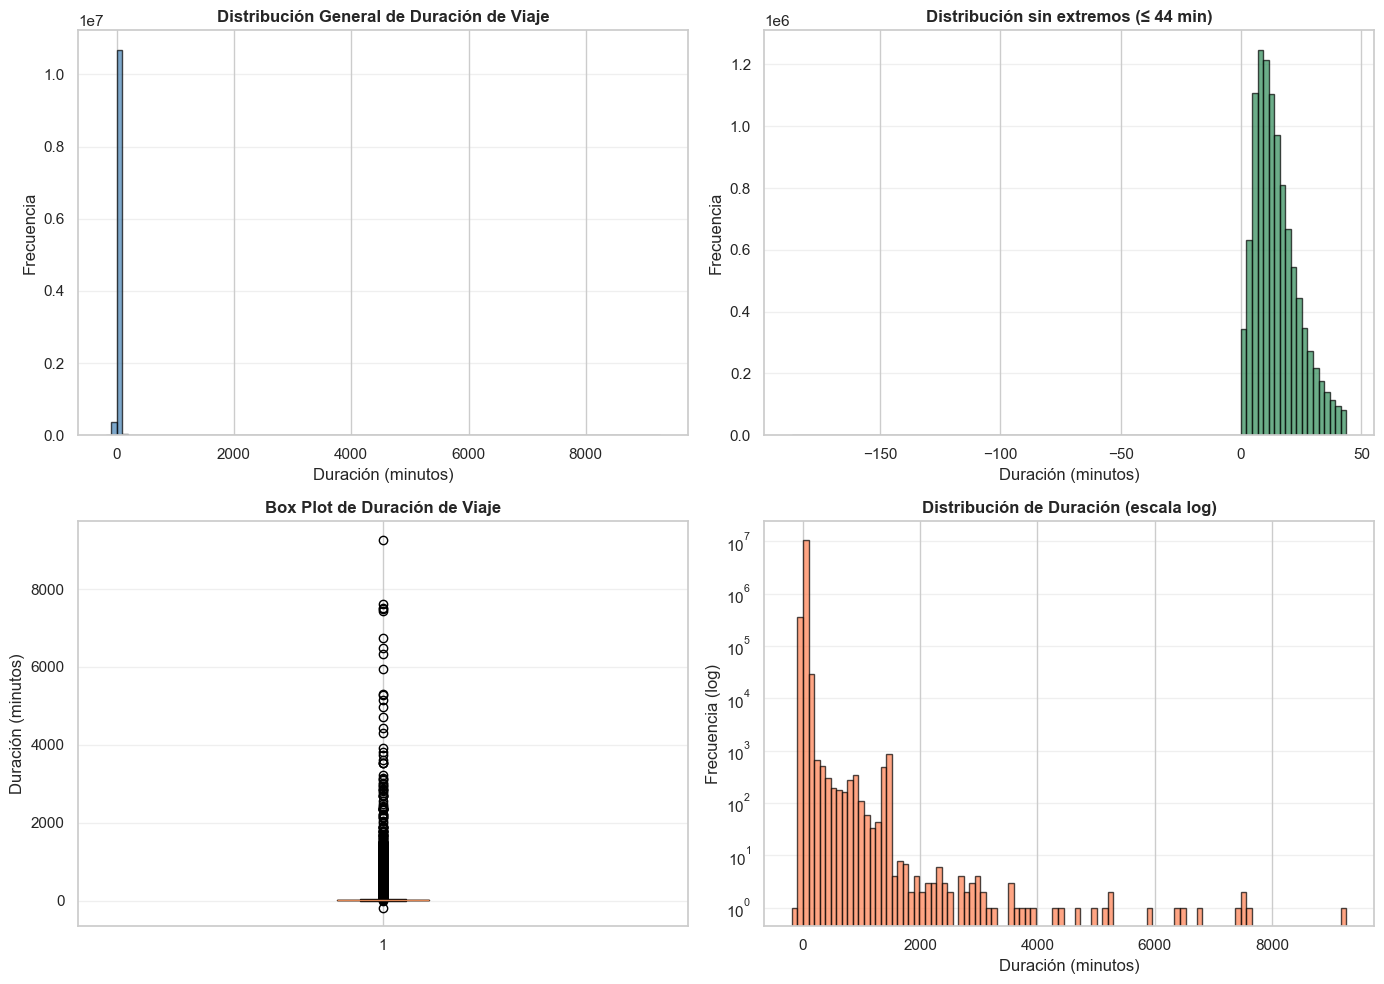

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(trip_duration_minutes, bins=100, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Distribución General de Duración de Viaje', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Duración (minutos)')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].grid(axis='y', alpha=0.3)

q95 = trip_duration_minutes.quantile(0.95)
filtered_duration = trip_duration_minutes[trip_duration_minutes <= q95]
axes[0, 1].hist(filtered_duration, bins=100, color='seagreen', edgecolor='black', alpha=0.7)
axes[0, 1].set_title(f'Distribución sin extremos (≤ {q95:.0f} min)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Duración (minutos)')
axes[0, 1].set_ylabel('Frecuencia')
axes[0, 1].grid(axis='y', alpha=0.3)

axes[1, 0].boxplot(trip_duration_minutes, vert=True)
axes[1, 0].set_title('Box Plot de Duración de Viaje', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Duración (minutos)')
axes[1, 0].grid(axis='y', alpha=0.3)

axes[1, 1].hist(trip_duration_minutes, bins=100, color='coral', edgecolor='black', alpha=0.7)
axes[1, 1].set_yscale('log')
axes[1, 1].set_title('Distribución de Duración (escala log)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Duración (minutos)')
axes[1, 1].set_ylabel('Frecuencia (log)')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [27]:
df_pd = df.to_pandas()

df_pd['trip_duration_min'] = trip_duration_minutes

print("=" * 80)
print("ANÁLISIS DE FEATURES")
print("=" * 80)

print("\n1. TRIP DISTANCE")
print(f"   Rango: {df_pd['trip_distance'].min():.2f} - {df_pd['trip_distance'].max():.2f} millas")
print(f"   Media: {df_pd['trip_distance'].mean():.2f} millas")
print(f"   Mediana: {df_pd['trip_distance'].median():.2f} millas")
print(f"   Viajes con distancia 0: {(df_pd['trip_distance'] == 0).sum()}")
print(f"   Viajes con distancia NEGATIVA: {(df_pd['trip_distance'] < 0).sum()}")

corr_dist_dur = df_pd['trip_distance'].corr(df_pd['trip_duration_min'])
print(f"   Correlación con duración: {corr_dist_dur:.4f}")

print("\n2. PASSENGER COUNT")
print(df_pd['passenger_count'].value_counts().sort_index().to_string())
print(f"   Valores únicos: {df_pd['passenger_count'].nunique()}")
print(f"   Valores 0 o negativos: {(df_pd['passenger_count'] <= 0).sum()}")

print("\n3. FARE AMOUNT")
print(f"   Rango: ${df_pd['fare_amount'].min():.2f} - ${df_pd['fare_amount'].max():.2f}")
print(f"   Media: ${df_pd['fare_amount'].mean():.2f}")
print(f"   Tarifa NEGATIVA: {(df_pd['fare_amount'] < 0).sum()}")
corr_fare_dur = df_pd['fare_amount'].corr(df_pd['trip_duration_min'])
print(f"   Correlación con duración: {corr_fare_dur:.4f}")

print("\n4. PICKUP/DROPOFF LOCATIONS")
print(f"   Ubicaciones pickup únicas: {df_pd['PULocationID'].nunique()}")
print(f"   Ubicaciones dropoff únicas: {df_pd['DOLocationID'].nunique()}")
print(f"   Mismo pickup y dropoff: {(df_pd['PULocationID'] == df_pd['DOLocationID']).sum()}")

print("\n5. PAYMENT TYPE")
print(df_pd['payment_type'].value_counts().sort_index().to_string())

print("\n6. VENDOR ID")
print(df_pd['VendorID'].value_counts().sort_index().to_string())

ANÁLISIS DE FEATURES

1. TRIP DISTANCE
   Rango: 0.00 - 328522.20 millas
   Media: 6.22 millas
   Mediana: 1.80 millas
   Viajes con distancia 0: 370198
   Viajes con distancia NEGATIVA: 0
   Correlación con duración: 0.0037

2. PASSENGER COUNT
passenger_count
0.0      40638
1.0    6630610
2.0     968664
3.0     206283
4.0     134234
5.0      25366
6.0      14274
7.0          2
8.0          9
9.0          3
   Valores únicos: 10
   Valores 0 o negativos: 40638

3. FARE AMOUNT
   Rango: $-2555.20 - $2555.20
   Media: $21.25
   Tarifa NEGATIVA: 86908
   Correlación con duración: 0.3743

4. PICKUP/DROPOFF LOCATIONS
   Ubicaciones pickup únicas: 262
   Ubicaciones dropoff únicas: 261
   Mismo pickup y dropoff: 519706

5. PAYMENT TYPE
payment_type
0    3057123
1    6910238
2     941200
3      41867
4     126778

6. VENDOR ID
VendorID
1    2112458
2    8811934
6      19072
7     133742


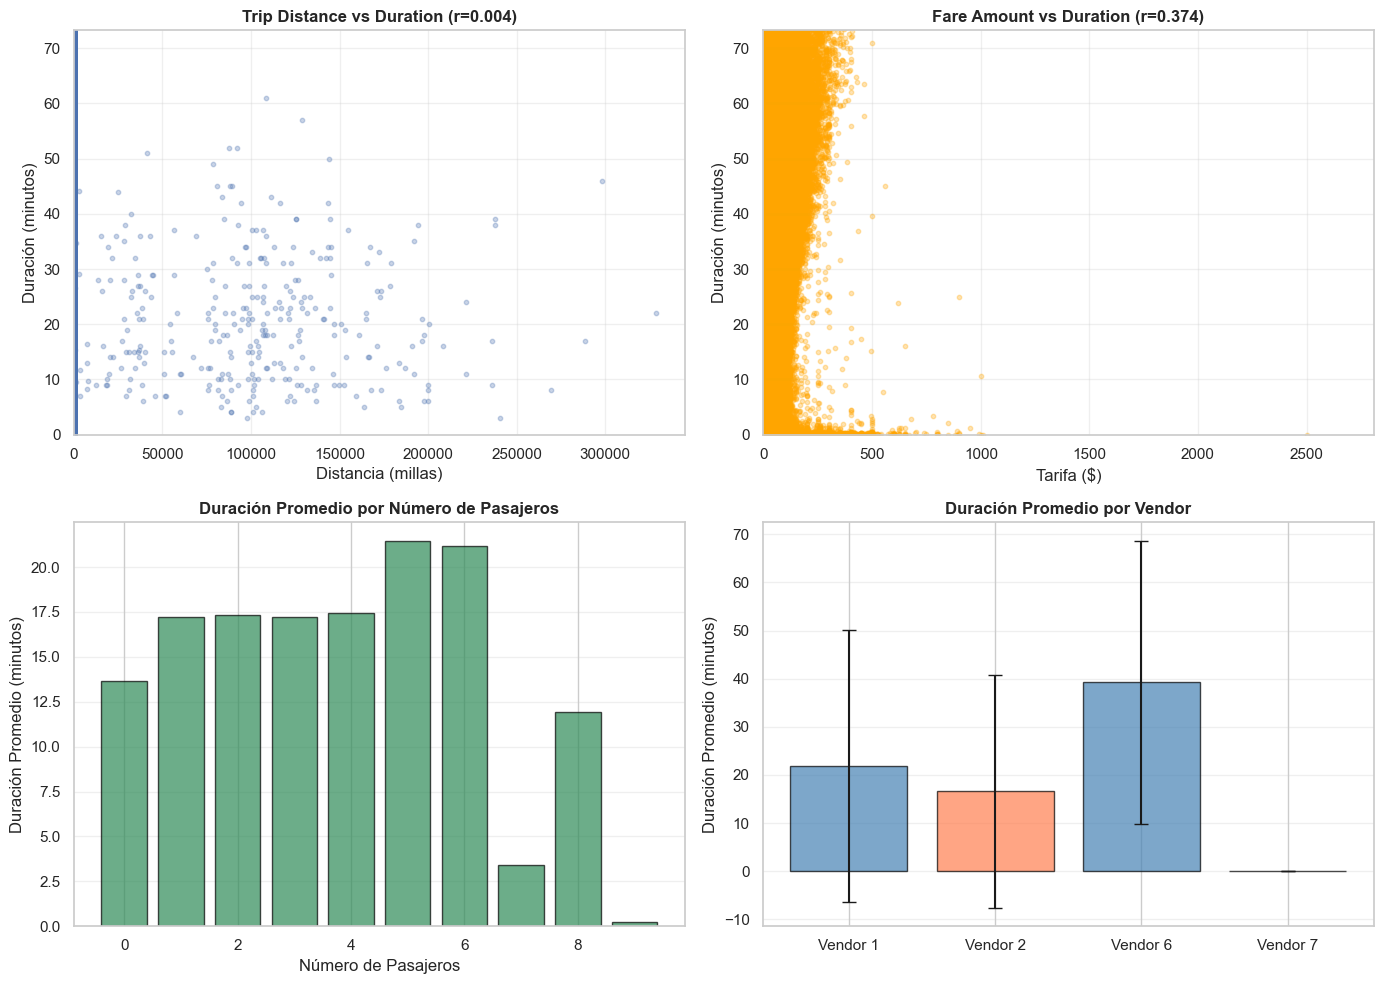

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].scatter(df_pd['trip_distance'], df_pd['trip_duration_min'], alpha=0.3, s=10)
axes[0, 0].set_xlabel('Distancia (millas)')
axes[0, 0].set_ylabel('Duración (minutos)')
axes[0, 0].set_title(f'Trip Distance vs Duration (r={corr_dist_dur:.3f})', fontweight='bold')
axes[0, 0].grid(alpha=0.3)
axes[0, 0].set_xlim(left=0)
axes[0, 0].set_ylim(bottom=0, top=trip_duration_minutes.quantile(0.99))

axes[0, 1].scatter(df_pd['fare_amount'], df_pd['trip_duration_min'], alpha=0.3, s=10, color='orange')
axes[0, 1].set_xlabel('Tarifa ($)')
axes[0, 1].set_ylabel('Duración (minutos)')
axes[0, 1].set_title(f'Fare Amount vs Duration (r={corr_fare_dur:.3f})', fontweight='bold')
axes[0, 1].grid(alpha=0.3)
axes[0, 1].set_xlim(left=-5)
axes[0, 1].set_ylim(bottom=0, top=trip_duration_minutes.quantile(0.99))

passenger_dur = df_pd.groupby('passenger_count')['trip_duration_min'].mean()
axes[1, 0].bar(passenger_dur.index, passenger_dur.values, color='seagreen', alpha=0.7, edgecolor='black')
axes[1, 0].set_xlabel('Número de Pasajeros')
axes[1, 0].set_ylabel('Duración Promedio (minutos)')
axes[1, 0].set_title('Duración Promedio por Número de Pasajeros', fontweight='bold')
axes[1, 0].grid(axis='y', alpha=0.3)

vendor_stats = df_pd.groupby('VendorID')['trip_duration_min'].agg(['mean', 'std', 'count'])
x_pos = range(len(vendor_stats))
axes[1, 1].bar(x_pos, vendor_stats['mean'], yerr=vendor_stats['std'], 
               alpha=0.7, color=['steelblue', 'coral'], capsize=5, edgecolor='black')
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels([f'Vendor {int(vid)}' for vid in vendor_stats.index])
axes[1, 1].set_ylabel('Duración Promedio (minutos)')
axes[1, 1].set_title('Duración Promedio por Vendor', fontweight='bold')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Visualización de outliers

In [29]:
print("=" * 80)
print("ANÁLISIS DE OUTLIERS Y ANOMALÍAS")
print("=" * 80)

Q1_dur = df_pd['trip_duration_min'].quantile(0.25)
Q3_dur = df_pd['trip_duration_min'].quantile(0.75)
IQR_dur = Q3_dur - Q1_dur
lower_bound_dur = Q1_dur - 1.5 * IQR_dur
upper_bound_dur = Q3_dur + 1.5 * IQR_dur

outliers_dur = df_pd[
    (df_pd['trip_duration_min'] < lower_bound_dur) | 
    (df_pd['trip_duration_min'] > upper_bound_dur)
]
print(f"\n1. TRIP DURATION OUTLIERS")
print(f"   Rango válido: {lower_bound_dur:.2f} - {upper_bound_dur:.2f} minutos")
print(f"   Outliers detectados: {len(outliers_dur)} ({(len(outliers_dur)/len(df_pd))*100:.2f}%)")

Q1_dist = df_pd['trip_distance'].quantile(0.25)
Q3_dist = df_pd['trip_distance'].quantile(0.75)
IQR_dist = Q3_dist - Q1_dist
upper_bound_dist = Q3_dist + 1.5 * IQR_dist

outliers_dist = df_pd[df_pd['trip_distance'] > upper_bound_dist]
print(f"\n2. TRIP DISTANCE OUTLIERS")
print(f"   Límite superior: {upper_bound_dist:.2f} millas")
print(f"   Outliers detectados: {len(outliers_dist)} ({(len(outliers_dist)/len(df_pd))*100:.2f}%)")

Q1_fare = df_pd['fare_amount'].quantile(0.25)
Q3_fare = df_pd['fare_amount'].quantile(0.75)
IQR_fare = Q3_fare - Q1_fare
lower_bound_fare = Q1_fare - 1.5 * IQR_fare
upper_bound_fare = Q3_fare + 1.5 * IQR_fare

outliers_fare = df_pd[
    (df_pd['fare_amount'] < lower_bound_fare) | 
    (df_pd['fare_amount'] > upper_bound_fare)
]
print(f"\n3. FARE AMOUNT OUTLIERS")
print(f"   Rango válido: ${lower_bound_fare:.2f} - ${upper_bound_fare:.2f}")
print(f"   Outliers detectados: {len(outliers_fare)} ({(len(outliers_fare)/len(df_pd))*100:.2f}%)")

print(f"\n4. CASOS ESPECÍFICOS")
problematic_rows = 0

duration_issues = (df_pd['trip_duration_min'] <= 0).sum()
print(f"   Duración ≤ 0: {duration_issues} filas")
problematic_rows += duration_issues

distance_issues = (df_pd['trip_distance'] <= 0).sum()
print(f"   Distancia ≤ 0: {distance_issues} filas")
problematic_rows += distance_issues

fare_issues = (df_pd['fare_amount'] < 0).sum()
print(f"   Tarifa < 0: {fare_issues} filas")
problematic_rows += fare_issues

passenger_issues = (df_pd['passenger_count'] <= 0).sum()
print(f"   Pasajeros ≤ 0: {passenger_issues} filas")
problematic_rows += passenger_issues

print(f"\n   TOTAL: {problematic_rows} problemas detectados")

ANÁLISIS DE OUTLIERS Y ANOMALÍAS

1. TRIP DURATION OUTLIERS
   Rango válido: -11.92 - 41.61 minutos
   Outliers detectados: 627028 (5.66%)

2. TRIP DISTANCE OUTLIERS
   Límite superior: 7.75 millas
   Outliers detectados: 1263479 (11.41%)

3. FARE AMOUNT OUTLIERS
   Rango válido: $-15.20 - $52.00
   Outliers detectados: 746328 (6.74%)

4. CASOS ESPECÍFICOS
   Duración ≤ 0: 134801 filas
   Distancia ≤ 0: 370198 filas
   Tarifa < 0: 86908 filas
   Pasajeros ≤ 0: 40638 filas

   TOTAL: 632545 problemas detectados


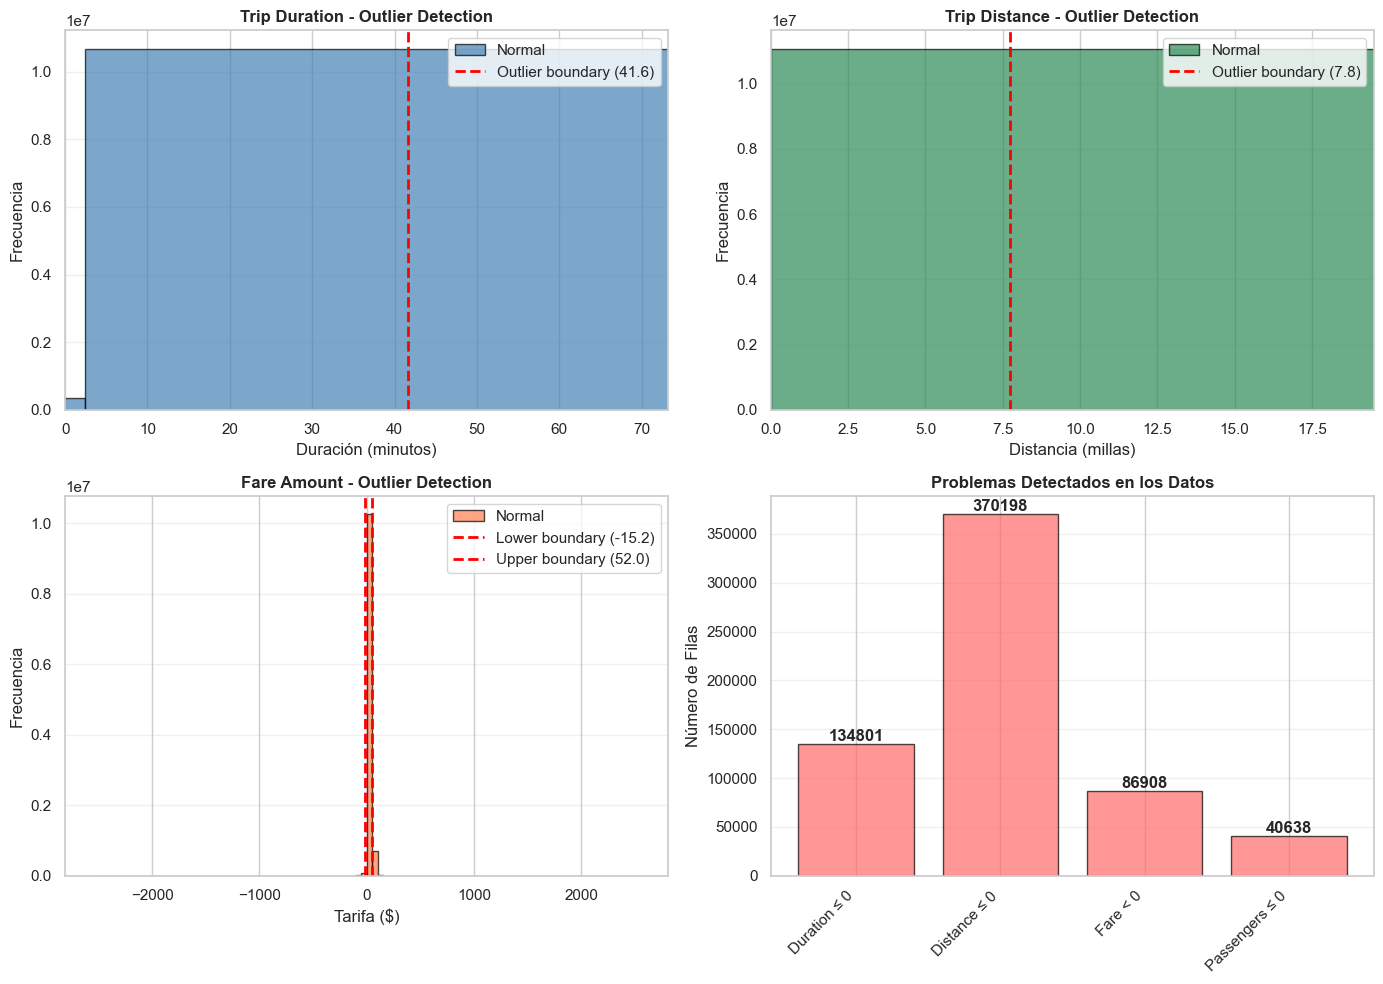

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax1 = axes[0, 0]
ax1.hist(df_pd['trip_duration_min'], bins=100, alpha=0.7, label='Normal', color='steelblue', edgecolor='black')
ax1.axvline(upper_bound_dur, color='red', linestyle='--', linewidth=2, label=f'Outlier boundary ({upper_bound_dur:.1f})')
ax1.set_xlabel('Duración (minutos)')
ax1.set_ylabel('Frecuencia')
ax1.set_title('Trip Duration - Outlier Detection', fontweight='bold')
ax1.legend()
ax1.set_xlim(left=0, right=df_pd['trip_duration_min'].quantile(0.99))
ax1.grid(axis='y', alpha=0.3)

ax2 = axes[0, 1]
ax2.hist(df_pd['trip_distance'], bins=100, alpha=0.7, label='Normal', color='seagreen', edgecolor='black')
ax2.axvline(upper_bound_dist, color='red', linestyle='--', linewidth=2, label=f'Outlier boundary ({upper_bound_dist:.1f})')
ax2.set_xlabel('Distancia (millas)')
ax2.set_ylabel('Frecuencia')
ax2.set_title('Trip Distance - Outlier Detection', fontweight='bold')
ax2.legend()
ax2.set_xlim(left=0, right=df_pd['trip_distance'].quantile(0.99))
ax2.grid(axis='y', alpha=0.3)

ax3 = axes[1, 0]
ax3.hist(df_pd['fare_amount'], bins=100, alpha=0.7, label='Normal', color='coral', edgecolor='black')
ax3.axvline(lower_bound_fare, color='red', linestyle='--', linewidth=2, label=f'Lower boundary ({lower_bound_fare:.1f})')
ax3.axvline(upper_bound_fare, color='red', linestyle='--', linewidth=2, label=f'Upper boundary ({upper_bound_fare:.1f})')
ax3.set_xlabel('Tarifa ($)')
ax3.set_ylabel('Frecuencia')
ax3.set_title('Fare Amount - Outlier Detection', fontweight='bold')
ax3.legend()
ax3.grid(axis='y', alpha=0.3)

ax4 = axes[1, 1]
problems = {
    'Duration ≤ 0': duration_issues,
    'Distance ≤ 0': distance_issues,
    'Fare < 0': fare_issues,
    'Passengers ≤ 0': passenger_issues
}
colors_prob = ['#ff6b6b' if v > 0 else '#d3d3d3' for v in problems.values()]
bars = ax4.bar(range(len(problems)), problems.values(), color=colors_prob, edgecolor='black', alpha=0.7)
ax4.set_xticks(range(len(problems)))
ax4.set_xticklabels(problems.keys(), rotation=45, ha='right')
ax4.set_ylabel('Número de Filas')
ax4.set_title('Problemas Detectados en los Datos', fontweight='bold')
ax4.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

In [31]:
print("=" * 80)
print("MATRIZ DE CORRELACIÓN")
print("=" * 80)

numeric_cols = ['trip_duration_min', 'trip_distance', 'fare_amount', 'passenger_count', 
                'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'total_amount']

numeric_cols = [col for col in numeric_cols if col in df_pd.columns]

correlation_matrix = df_pd[numeric_cols].corr()['trip_duration_min'].sort_values(ascending=False)

print("\nCorrelación con TRIP_DURATION:")
for feature, corr_val in correlation_matrix.items():
    print(f"  {feature:25} : {corr_val:7.4f}")

print("\n" + "=" * 80)
print("ANÁLISIS TEMPORAL")
print("=" * 80)

df_pd['hour'] = pd.to_datetime(df_pd['tpep_pickup_datetime']).dt.hour
df_pd['day_of_week'] = pd.to_datetime(df_pd['tpep_pickup_datetime']).dt.day_name()
df_pd['month'] = pd.to_datetime(df_pd['tpep_pickup_datetime']).dt.month

print(f"\nRango de fechas:")
print(f"  Inicio: {pd.to_datetime(df_pd['tpep_pickup_datetime']).min()}")
print(f"  Fin: {pd.to_datetime(df_pd['tpep_pickup_datetime']).max()}")

hour_avg = df_pd.groupby('hour')['trip_duration_min'].agg(['mean', 'count'])
print(f"\nDuración promedio por HORA DEL DÍA:")
for hour, row in hour_avg.iterrows():
    print(f"  Hora {hour:2d}: {row['mean']:6.2f} min (n={int(row['count']):7d})")

print(f"\nDuración promedio por DÍA DE LA SEMANA:")
day_avg = df_pd.groupby('day_of_week')['trip_duration_min'].agg(['mean', 'count'])
for day, row in day_avg.iterrows():
    print(f"  {day:12}: {row['mean']:6.2f} min (n={int(row['count']):7d})")

MATRIZ DE CORRELACIÓN

Correlación con TRIP_DURATION:
  trip_duration_min         :  1.0000
  fare_amount               :  0.3743
  total_amount              :  0.3598
  tolls_amount              :  0.2059
  tip_amount                :  0.1480
  extra                     :  0.0100
  passenger_count           :  0.0071
  trip_distance             :  0.0037
  mta_tax                   : -0.0035

ANÁLISIS TEMPORAL

Rango de fechas:
  Inicio: 2008-12-31 23:03:20
  Fin: 2026-04-01 00:06:25

Duración promedio por HORA DEL DÍA:
  Hora  0:  14.96 min (n= 334267)
  Hora  1:  14.58 min (n= 225395)
  Hora  2:  13.50 min (n= 149586)
  Hora  3:  13.72 min (n= 112922)
  Hora  4:  15.57 min (n=  92559)
  Hora  5:  19.05 min (n= 101535)
  Hora  6:  20.22 min (n= 194245)
  Hora  7:  19.26 min (n= 344011)
  Hora  8:  18.76 min (n= 452234)
  Hora  9:  18.12 min (n= 465896)
  Hora 10:  18.03 min (n= 468834)
  Hora 11:  18.16 min (n= 499246)
  Hora 12:  18.27 min (n= 539831)
  Hora 13:  18.58 min (n= 56167

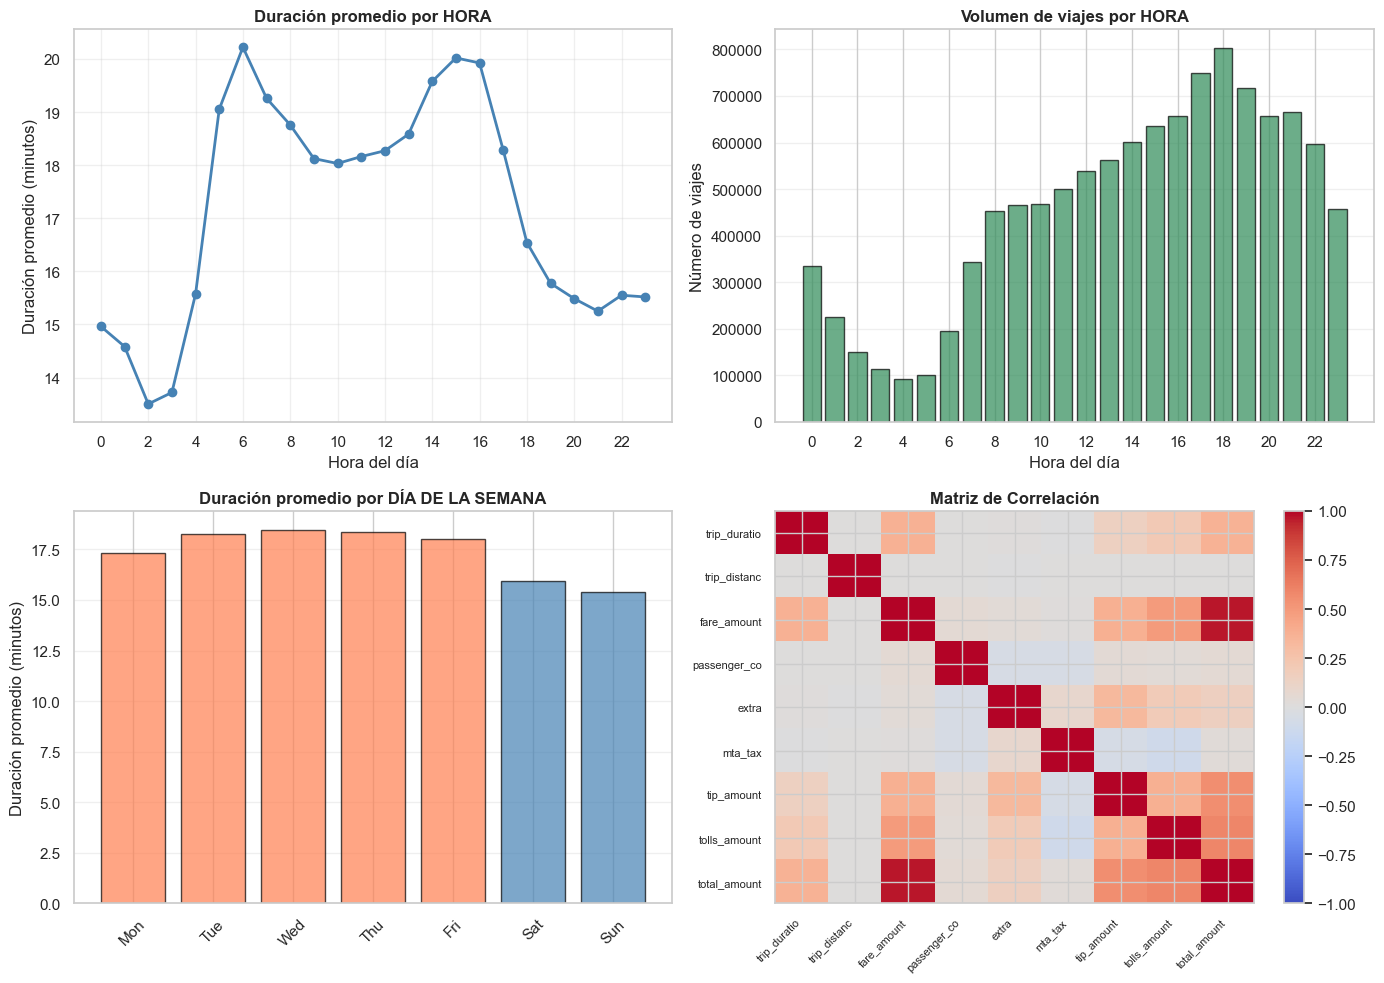

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

hour_stats = df_pd.groupby('hour')['trip_duration_min'].mean()
axes[0, 0].plot(hour_stats.index, hour_stats.values, marker='o', color='steelblue', linewidth=2)
axes[0, 0].set_xlabel('Hora del día')
axes[0, 0].set_ylabel('Duración promedio (minutos)')
axes[0, 0].set_title('Duración promedio por HORA', fontweight='bold')
axes[0, 0].grid(alpha=0.3)
axes[0, 0].set_xticks(range(0, 24, 2))

hour_counts = df_pd.groupby('hour').size()
axes[0, 1].bar(hour_counts.index, hour_counts.values, color='seagreen', alpha=0.7, edgecolor='black')
axes[0, 1].set_xlabel('Hora del día')
axes[0, 1].set_ylabel('Número de viajes')
axes[0, 1].set_title('Volumen de viajes por HORA', fontweight='bold')
axes[0, 1].grid(axis='y', alpha=0.3)
axes[0, 1].set_xticks(range(0, 24, 2))

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_stats = df_pd.groupby('day_of_week')['trip_duration_min'].mean().reindex(day_order)
colors_days = ['steelblue' if day in ['Saturday', 'Sunday'] else 'coral' for day in day_order]
axes[1, 0].bar(range(len(day_stats)), day_stats.values, color=colors_days, alpha=0.7, edgecolor='black')
axes[1, 0].set_xticks(range(len(day_stats)))
axes[1, 0].set_xticklabels([day[:3] for day in day_order], rotation=45)
axes[1, 0].set_ylabel('Duración promedio (minutos)')
axes[1, 0].set_title('Duración promedio por DÍA DE LA SEMANA', fontweight='bold')
axes[1, 0].grid(axis='y', alpha=0.3)

correlation_subset = df_pd[numeric_cols].corr()
im = axes[1, 1].imshow(correlation_subset, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
axes[1, 1].set_xticks(range(len(numeric_cols)))
axes[1, 1].set_yticks(range(len(numeric_cols)))
axes[1, 1].set_xticklabels([col[:12] for col in numeric_cols], rotation=45, ha='right', fontsize=8)
axes[1, 1].set_yticklabels([col[:12] for col in numeric_cols], fontsize=8)
axes[1, 1].set_title('Matriz de Correlación', fontweight='bold')
plt.colorbar(im, ax=axes[1, 1])

plt.tight_layout()
plt.show()

## Exploración de datos para Random Forest

In [33]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder

print("=" * 80)
print("RANDOM FOREST - FEATURE IMPORTANCE")
print("=" * 80)

sample_size = min(500000, len(df_pd))
df_sample = df_pd.sample(n=sample_size, random_state=42).copy()

feature_cols = [
    'trip_distance',
    'passenger_count', 
    'VendorID',
    'PULocationID',
    'DOLocationID',
    'payment_type',
    'RatecodeID'
]

df_sample['hour'] = pd.to_datetime(df_sample['tpep_pickup_datetime']).dt.hour
df_sample['day_of_week'] = pd.to_datetime(df_sample['tpep_pickup_datetime']).dt.dayofweek
df_sample['is_weekend'] = df_sample['day_of_week'].isin([5, 6]).astype(int)

feature_cols.extend(['hour', 'day_of_week', 'is_weekend'])

y = df_sample['trip_duration_min'].values

df_sample_clean = df_sample[feature_cols + ['trip_duration_min']].dropna()
X = df_sample_clean[feature_cols].values
y = df_sample_clean['trip_duration_min'].values

print(f"  Dataset para RF: {len(X):,} muestras, {len(feature_cols)} features")

print("\n Entrenando Random Forest")
rf = RandomForestRegressor(
    n_estimators=50,  # Menos árboles para rapidez
    max_depth=12,
    n_jobs=-1,
    random_state=42,
    verbose=1
)
rf.fit(X, y)

feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

feature_importance['Importance_Pct'] = (feature_importance['Importance'] * 100).round(2)

print("\n" + "=" * 80)
print("FEATURE IMPORTANCE RANKING")
print("=" * 80)
print(feature_importance[['Feature', 'Importance_Pct']].to_string(index=False))

from sklearn.metrics import r2_score, mean_absolute_percentage_error

y_pred = rf.predict(X)
r2 = r2_score(y, y_pred)
mape = mean_absolute_percentage_error(y, y_pred)

print(f"\n Performance en datos de entrenamiento (muestra {sample_size:,}):")
print(f"  R² Score: {r2:.4f} ({r2*100:.2f}%)")
print(f"  MAPE: {mape:.4f} ({mape*100:.2f}%)")
print(f"\nEl modelo captura {r2*100:.1f}% de la varianza")
print(f"Error promedio: ±{mape*100:.1f}%")

RANDOM FOREST - FEATURE IMPORTANCE
  Dataset para RF: 361,997 muestras, 10 features

 Entrenando Random Forest


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    4.0s



FEATURE IMPORTANCE RANKING
        Feature  Importance_Pct
  trip_distance           42.47
           hour           13.57
   PULocationID           13.50
   DOLocationID           12.11
    day_of_week            6.49
     RatecodeID            6.36
passenger_count            1.96
       VendorID            1.25
   payment_type            1.25
     is_weekend            1.04

 Performance en datos de entrenamiento (muestra 500,000):
  R² Score: 0.5856 (58.56%)
  MAPE: 9587278945041.7969 (958727894504179.75%)

El modelo captura 58.6% de la varianza
Error promedio: ±958727894504179.8%


[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:    7.6s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    0.0s finished


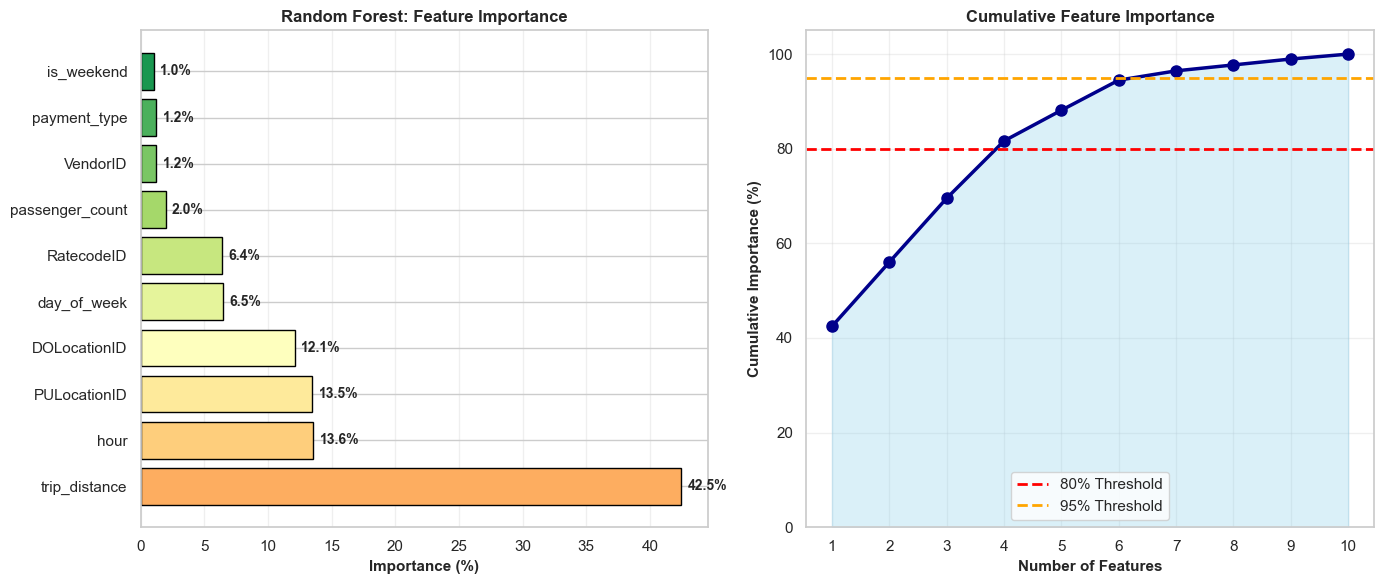


Para explicar 80% de varianza: 7 features
  - trip_distance, hour, PULocationID, DOLocationID, day_of_week, RatecodeID, passenger_count

Para explicar 95% de varianza: 4 features
  - trip_distance, hour, PULocationID, DOLocationID
 Se puede descartar payment_type, VendorID, is_weekend (bajo aporte)
 MAPE alto arriba es por outliers extremos, el R² real (58.6%) es lo importante


In [34]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

colors_imp = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(feature_importance)))
ax1.barh(range(len(feature_importance)), feature_importance['Importance_Pct'], color=colors_imp, edgecolor='black')
ax1.set_yticks(range(len(feature_importance)))
ax1.set_yticklabels(feature_importance['Feature'])
ax1.set_xlabel('Importance (%)', fontsize=11, fontweight='bold')
ax1.set_title('Random Forest: Feature Importance', fontsize=12, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

for i, (feat, imp) in enumerate(zip(feature_importance['Feature'], feature_importance['Importance_Pct'])):
    ax1.text(imp + 0.5, i, f'{imp:.1f}%', va='center', fontweight='bold', fontsize=10)

cumsum_imp = feature_importance['Importance_Pct'].cumsum()
ax2.plot(range(len(feature_importance)), cumsum_imp, marker='o', linewidth=2.5, markersize=8, color='darkblue')
ax2.fill_between(range(len(feature_importance)), cumsum_imp, alpha=0.3, color='skyblue')
ax2.axhline(y=80, color='red', linestyle='--', linewidth=2, label='80% Threshold')
ax2.axhline(y=95, color='orange', linestyle='--', linewidth=2, label='95% Threshold')
ax2.set_xlabel('Number of Features', fontsize=11, fontweight='bold')
ax2.set_ylabel('Cumulative Importance (%)', fontsize=11, fontweight='bold')
ax2.set_title('Cumulative Feature Importance', fontsize=12, fontweight='bold')
ax2.set_xticks(range(len(feature_importance)))
ax2.set_xticklabels(range(1, len(feature_importance) + 1))
ax2.grid(alpha=0.3)
ax2.legend()
ax2.set_ylim(0, 105)

plt.tight_layout()
plt.show()


cumsum = feature_importance['Importance_Pct'].cumsum()
features_80 = (cumsum >= 80).sum()
features_95 = (cumsum >= 95).sum()

print(f"\nPara explicar 80% de varianza: {features_80} features")
print(f"  - {', '.join(feature_importance.head(features_80)['Feature'].tolist())}")

print(f"\nPara explicar 95% de varianza: {features_95} features")
print(f"  - {', '.join(feature_importance.head(features_95)['Feature'].tolist())}")

print(f" Se puede descartar payment_type, VendorID, is_weekend (bajo aporte)")
print(f" MAPE alto arriba es por outliers extremos, el R² real (58.6%) es lo importante")